####======================================================
### **Homework Assignment 3**
### Saurav Luthra, 55027009
### **ECE 648 - Machine Learning**

#### ====================================================
#### INTRODUCTION + OVERVIEW
#### ======================================================

This assignment focuses on analyzing vertebral column data from *Vertebral_column_3C.dat* to examine relationships between biomechanical features and the orthopaedic patients' classes (disk hernia, normal, spondilolysthesis). The dataset contains 310 data points (rows) and has 7 features (columns), including the label. The aim is to effectively classify/predict the patient class, as a function of 6 features. To achieve this the sklearn, numpy, pandas, seaborn, and matplotlib packages were used. The following steps were performed:

1. Values for 6 independent variables/features (unnamed) and the class, *label*, were loaded into a DataFrame. The data was split into a training set and testing set.

2. Several support vector machine (SVM) classifiers were built with different combinations of kernels and values for the hyperparameter C. They were each used to predict the class lables of the test data.

3. Each of the models' confusion matrices, metrics, and prediction accuracies were calculated and displayed.


#### ====================================================
#### IMPORT PACKAGES
#### ======================================================

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

#### ====================================================
#### LOAD DATA INTO DATAFRAME
#### ======================================================

In [100]:
# create dataframe (df) from the input file
df = pd.read_csv('Vertebral_column_3C.dat', sep = '\s+', header = None)

# check df columns for missing values
df.isnull().sum().to_frame().transpose()

,0,1,2,3,4,5,6
0,0,0,0,0,0,0,0


In [101]:
# make X matrix
X = df.iloc[:, :6].rename(columns = {0: 'f0', 1: 'f1', 2: 'f2', 3: 'f3', 4: 'f4', 5: 'f5'})

X

,f0,f1,f2,f3,f4,f5
0,63.03,22.55,39.61,40.48,98.67,-0.25
1,39.06,10.06,25.02,29.00,114.41,4.56
2,68.83,22.22,50.09,46.61,105.99,-3.53
3,69.30,24.65,44.31,44.64,101.87,11.21
4,49.71,9.65,28.32,40.06,108.17,7.92
...,...,...,...,...,...,...
305,47.90,13.62,36.00,34.29,117.45,-4.25
306,53.94,20.72,29.22,33.22,114.37,-0.42
307,61.45,22.69,46.17,38.75,125.67,-2.71
308,45.25,8.69,41.58,36.56,118.55,0.21


In [102]:
# make y vector and map the labels to integers
# 0 - disk hernia       - DH
# 1 - spondilolysthesis - SL
# 2 - normal            - NO

y = df.iloc[:, 6:].rename(columns={6: 'label'})

mapping = {'DH': 0, 'SL': 1, 'NO': 2}
y['label'] = y['label'].map(mapping)

y

,label
0,0
1,0
2,0
3,0
4,0
...,...
305,2
306,2
307,2
308,2


In [103]:
#split data into a training set (70%) and a testing set (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1, stratify = y)

In [104]:
#standardize features (training and testing dataset)
sc = StandardScaler()
sc.fit(X_train)

X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [105]:
# transform the y vectors to be 1D arrays
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

#### ====================================================
#### BUILD SVM CLASSIFIERS
#### ======================================================

In [106]:
# list of kernels to use
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# list of values to use for hyperparameter c
c_vals = [0.01, 0.1, 1, 10, 100, 1000]

# class label names [disk hernia, spondylolisthesis, normal]
class_labels = ["DH", "SL", "NO"]

In [107]:
# 2d array for accuracy scores across kernel, c-value combinations
accuracy_arr = np.empty((len(c_vals), len(kernels)), dtype = object)

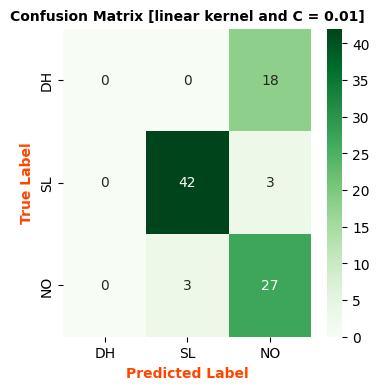

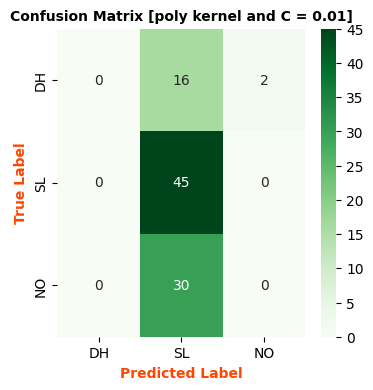

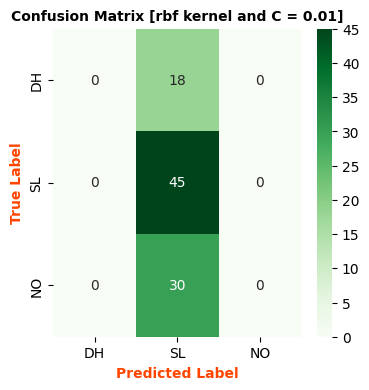

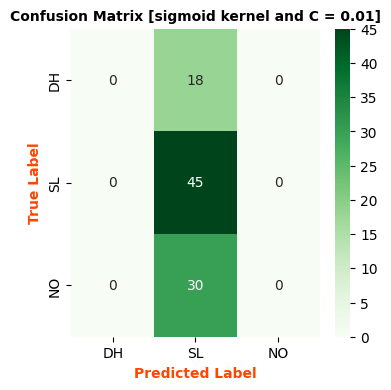

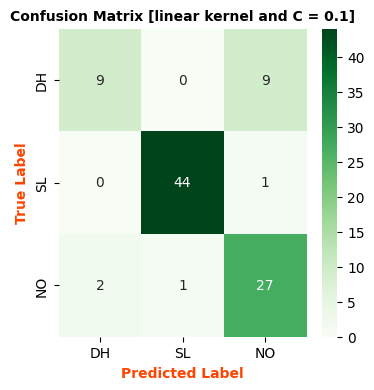

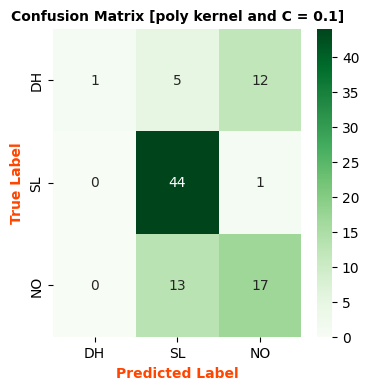

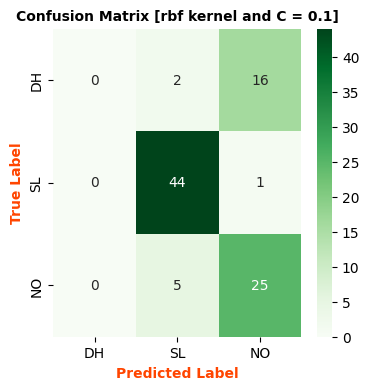

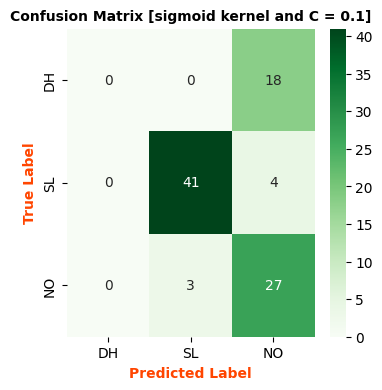

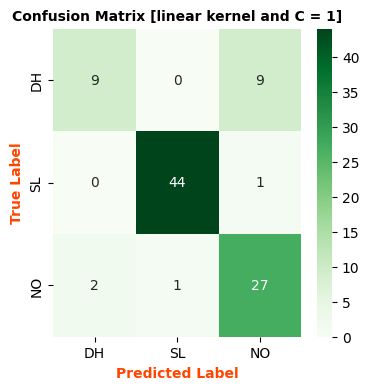

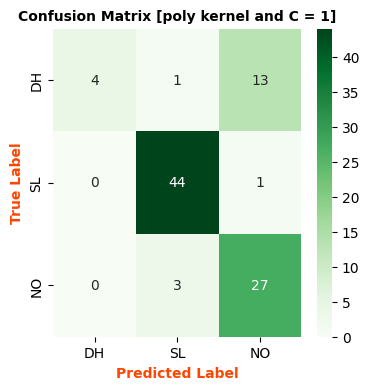

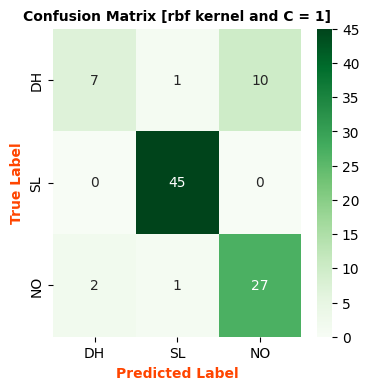

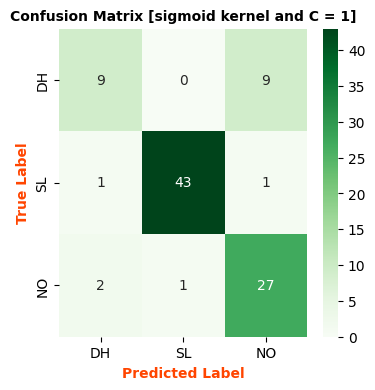

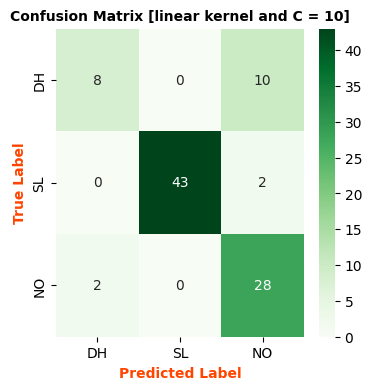

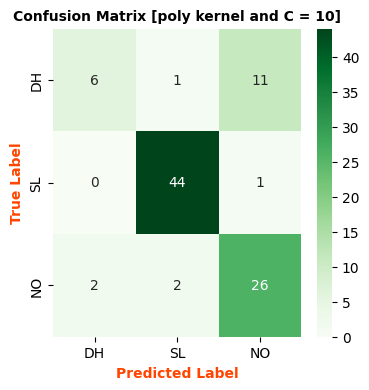

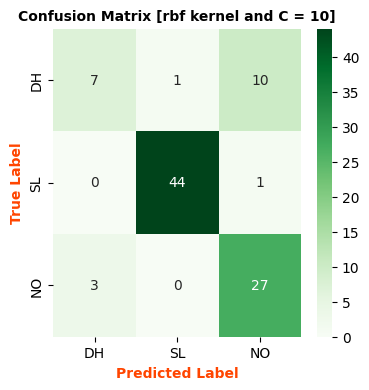

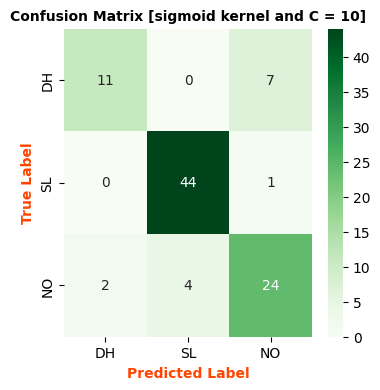

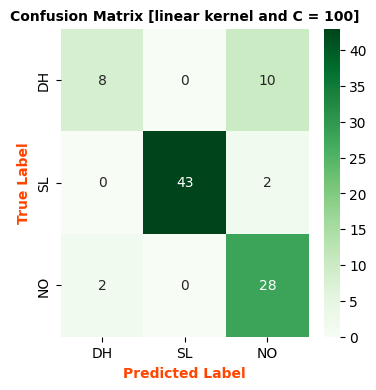

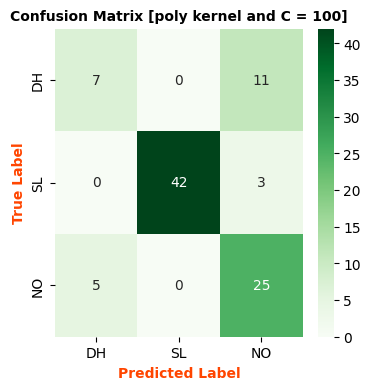

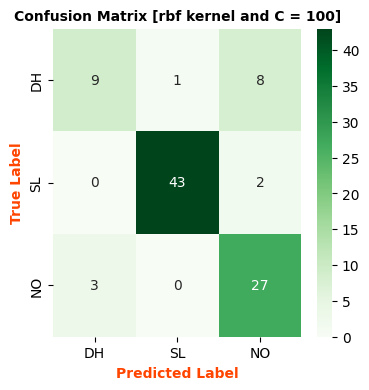

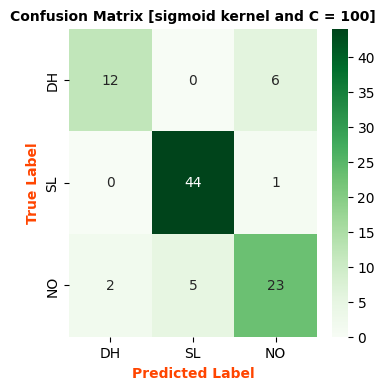

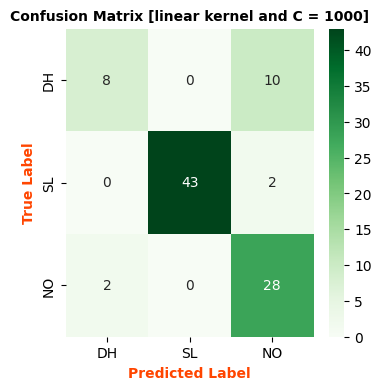

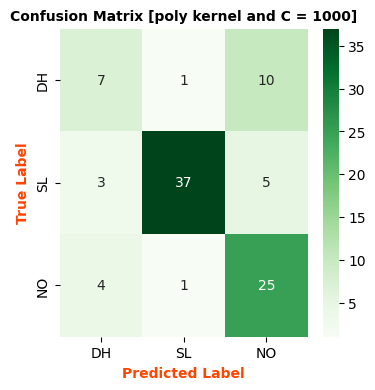

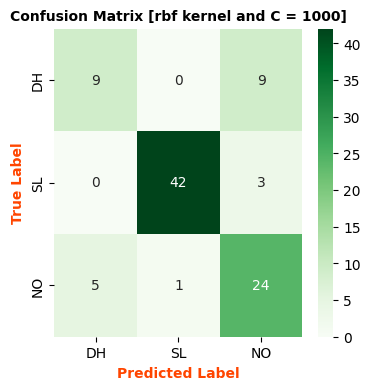

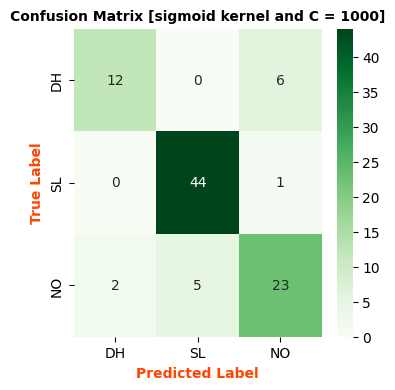

In [108]:
# build a variety of support vector machine classifiers using different kernels and c-values
for c_idx, c in enumerate(c_vals):

    for k_idx, kernel in enumerate(kernels):

        # build model and train on X_train and y_train.
        svm_classifier = SVC(kernel = kernel, C = c)
        svm_classifier.fit(X_train, y_train)

        # predict y-values on test dataset
        y_pred = svm_classifier.predict(X_test)

        # add accuracy score to the 2d array accuracy_arr
        accuracy = accuracy_score(y_test, y_pred)
        accuracy_arr[c_idx, k_idx] = f"{accuracy:.3f}"

        #create and plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize = (4, 4))
        sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Greens', xticklabels = class_labels, yticklabels = class_labels)
        plt.title(f"Confusion Matrix [{kernel} kernel and C = {c}]", fontsize = 10, color = "black", fontweight = "bold")
        plt.xlabel(f"Predicted Label", fontsize = 10, color = "orangered", fontweight = "bold")
        plt.ylabel(f"True Label", fontsize = 10, color = "orangered", fontweight = "bold")
        plt.show()

#### ====================================================
#### DISPLAY SVM CLASSIFIER RESULTS
#### ======================================================

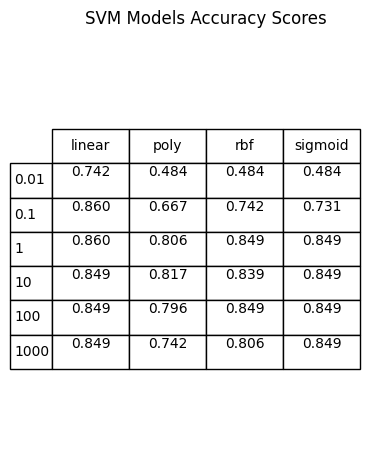

In [109]:
# create a figure and a set of subplots for the accuracy score table
fig, ax = plt.subplots()

# hide axes
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)

# create the table
table = plt.table(cellText = [[None] * len(kernels) for _ in range(len(c_vals))],
                  colLabels = kernels, rowLabels = c_vals, cellLoc = 'center', loc = 'center')

# add text values of the acccuracy score to each cell in the table
for c_idx, c_val in enumerate(c_vals):
    for k_idx, kernel in enumerate(kernels):

        table[(c_idx + 1, k_idx)].get_text().set_text(f"{accuracy_arr[c_idx, k_idx]}\n")


ax.set_title('SVM Models Accuracy Scores', fontsize = 12, pad = 10)

# set the font size
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.8, 1.8)

# adjust layout
plt.tight_layout()
plt.show()


#### ====================================================
#### CONCLUSION + DISCUSSION
#### ======================================================

____________________________________________________________

**Support Vector Machine Classifier:**

Lowest Prediction Accuracy: 0.484

Lowest Prediction Accuracy: 0.860

____________________________________________________________


A total of 24 SVM classifiers were built (4 kernels x 6 C-values). All of the classifiers were trained on the same training set of standardized data (to account for variations in the magnitude of features), and were tested on the same test set.

The accuracy scores were displayed in the table above and for this dataset, it seems that the best accuracy was achieved by the linear kernel with C = 0.1 or C = 1.

